<a href="https://colab.research.google.com/github/mariaragaodev/credit-card-fraud-detection/blob/main/deteccao_fraude_cartao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Detecção de Anomalias em Transações em Python**

### **Introdução**

Este projeto tem como objetivo desenvolver modelos de Machine Learning para identificar transações fraudulentas em uma base de dados de cartões de crédito.

O principal desafio desse problema é o forte desbalanceamento entre as classes. A grande maioria das transações é normal, enquanto uma pequena parcela corresponde a transações fraudulentas.

Nesse cenário, a acurácia pode ser enganosa. Um modelo que classifique quase todas as transações como normais pode apresentar uma acurácia elevada mesmo sendo incapaz de identificar fraudes.

Por esse motivo, este projeto utiliza principalmente precision, recall e F1-score para avaliar a classe de fraude.

### **Importação de bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import shap

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


### **Coleta de dados**

O dataset será carregado diretamente por meio de uma URL.

A coluna `Class` representa a variável que queremos prever:

- `0`: transação normal;
- `1`: transação fraudulenta.

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

print("Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Dataset carregado com sucesso!
Linhas: 284807
Colunas: 31


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


### **Conhecendo os dados**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


In [6]:
print("Valores ausentes:")
print(df.isnull().sum().sum())

Valores ausentes:
0


In [7]:
print("Duplicatas:")
print(df.duplicated().sum())

Duplicatas:
1081


### **Distribuição das classes**

In [8]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0   99.8273
1    0.1727
Name: proportion, dtype: float64


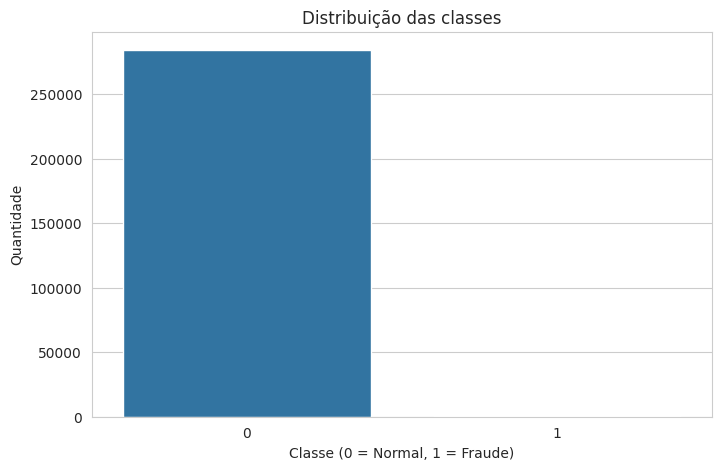

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribuição das classes")
plt.xlabel("Classe (0 = Normal, 1 = Fraude)")
plt.ylabel("Quantidade")

plt.show()

### **Análise do desbalanceamento**

A distribuição das classes demonstra que as transações normais representam a grande maioria dos registros, enquanto as transações fraudulentas são uma pequena parcela da base.

Esse desbalanceamento é importante porque um modelo poderia alcançar uma acurácia elevada simplesmente classificando a maioria das transações como normais.

Por isso, a acurácia não será utilizada como principal critério de avaliação. O projeto dará maior atenção ao precision, recall e F1-score da classe 1, que representa as fraudes.

### **Feature Engineering**

In [11]:
df["Amount_log"] = np.log1p(df["Amount"])

df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
0,149.6200,5.0148
1,2.6900,1.3056
2,378.6600,5.9393
3,123.5000,4.8243
4,69.9900,4.2625


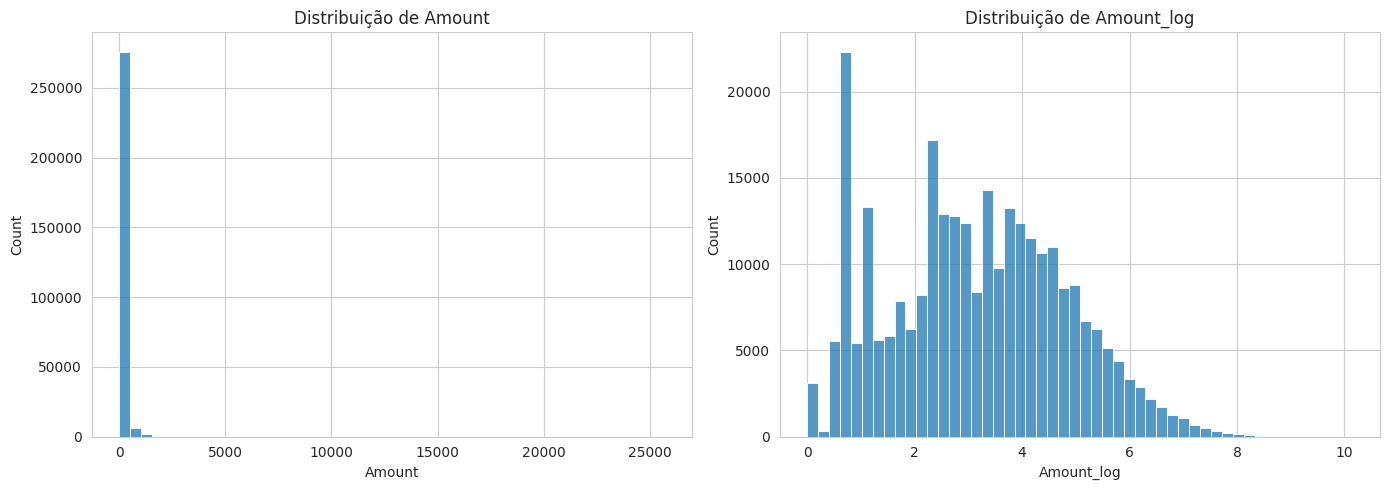

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Amount"],
    bins=50,
    ax=axes[0]
)

axes[0].set_title("Distribuição de Amount")
axes[0].set_xlabel("Amount")

sns.histplot(
    df["Amount_log"],
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Distribuição de Amount_log")
axes[1].set_xlabel("Amount_log")

plt.tight_layout()
plt.show()

### **Separação X e y**

A variável `X` contém as características utilizadas pelos modelos para realizar as previsões.

A variável `y` contém o resultado que queremos prever, representado pela coluna `Class`.

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (284807, 31)
Dimensão de y: (284807,)


### **Treino e teste**

Os dados serão divididos em 70% para treinamento e 30% para teste.

O parâmetro `stratify=y` mantém a proporção das classes nos dois conjuntos.

O conjunto de teste permanecerá separado para avaliar o comportamento dos modelos em dados que não foram utilizados durante o treinamento.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (199364, 31)
Teste: (85443, 31)


In [16]:
print("Distribuição no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True))

Distribuição no treino:
Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64

Distribuição no teste:
Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64


### **Regressão Logística**

O objetivo é criar uma referência inicial para posteriormente comparar o desempenho com Random Forest e XGBoost.

O `StandardScaler` será utilizado dentro de um Pipeline para evitar vazamento de informações entre treino e teste.

In [17]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

y_pred_logistic = logistic_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

### **Avaliação da Regressão Logística**

In [18]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9998    0.9783    0.9889     85295
      Fraude     0.0655    0.8784    0.1219       148

    accuracy                         0.9781     85443
   macro avg     0.5326    0.9283    0.5554     85443
weighted avg     0.9982    0.9781    0.9874     85443



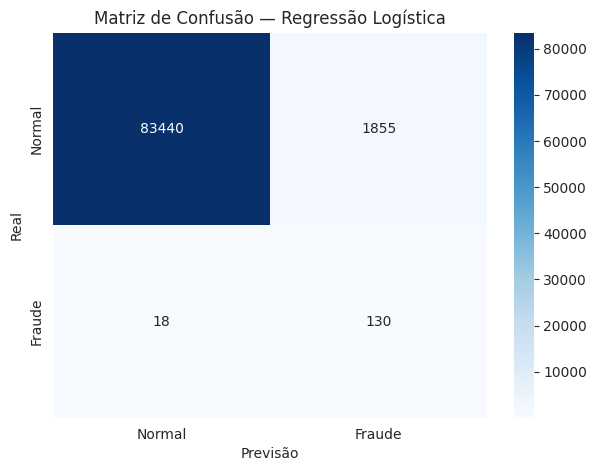

In [19]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraude"],
    yticklabels=["Normal", "Fraude"]
)

plt.title("Matriz de Confusão — Regressão Logística")
plt.xlabel("Previsão")
plt.ylabel("Real")

plt.show()

### **Curva ROC**

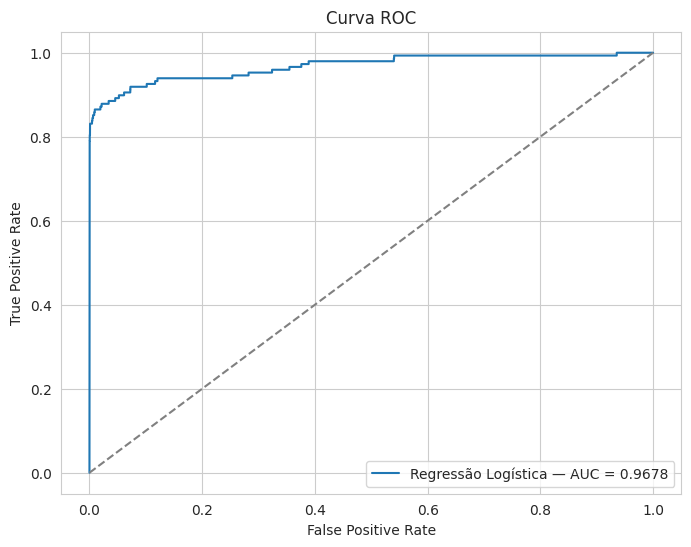

AUC: 0.9678


In [20]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_logistic
)

auc_log = roc_auc_score(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Regressão Logística — AUC = {auc_log:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

print(f"AUC: {auc_log:.4f}")

### **Curva Precision-Recall**

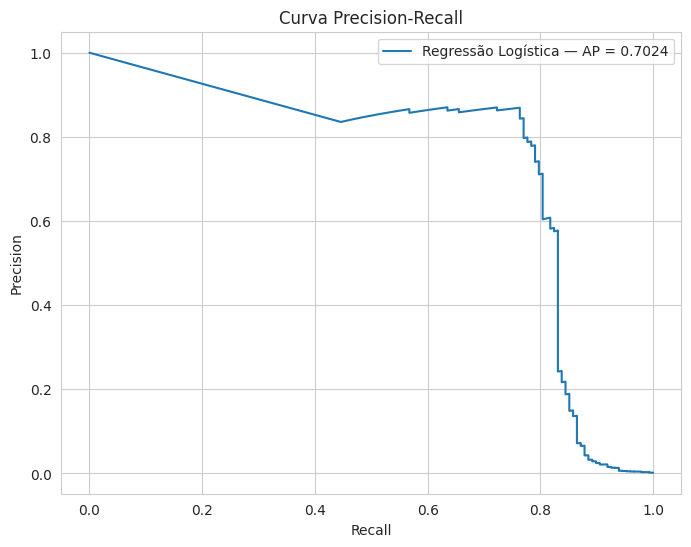

Average Precision: 0.7024


In [21]:
precision_log, recall_log, thresholds_log = precision_recall_curve(
    y_test,
    y_prob_logistic
)

ap_log = average_precision_score(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label=f"Regressão Logística — AP = {ap_log:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()

plt.show()

print(f"Average Precision: {ap_log:.4f}")

### **Ajuste do threshold**

In [22]:
thresholds_to_test = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (
        y_prob_logistic >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1000,0.0101,0.9392,0.0199
1,0.1500,0.0147,0.9257,0.0289
2,0.2000,0.0199,0.9189,0.0390
3,0.2500,0.0253,0.8986,0.0491
4,0.3000,0.0312,0.8919,0.0602
5,0.3500,0.0381,0.8851,0.0731
6,0.4000,0.0461,0.8784,0.0876
7,0.4500,0.0553,0.8784,0.1040
8,0.5000,0.0655,0.8784,0.1219
9,0.5500,0.0767,0.8649,0.1409


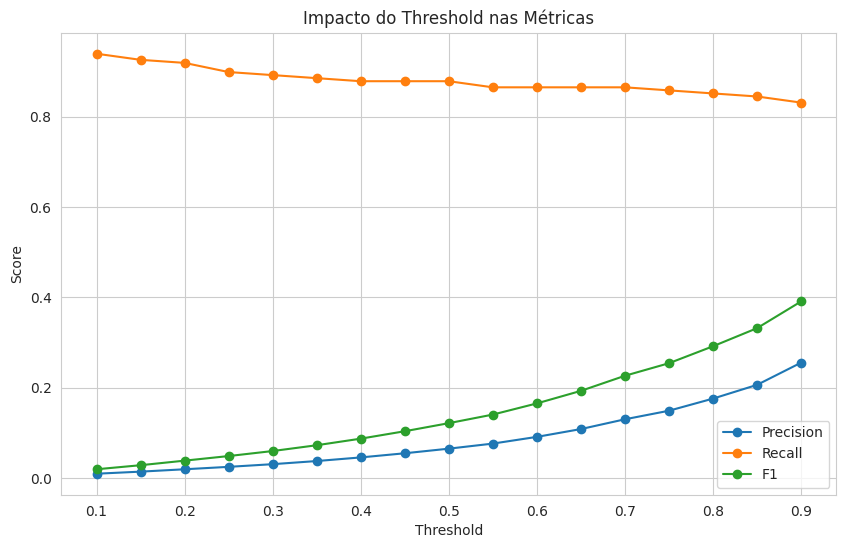

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Impacto do Threshold nas Métricas")
plt.legend()
plt.grid(True)

plt.show()

### **Escolha do threshold**

In [24]:
threshold_df[
    threshold_df["Recall"] >= 0.80
].sort_values(
    "Precision",
    ascending=False
)

,Threshold,Precision,Recall,F1
16,0.9000,0.2557,0.8311,0.3911
15,0.8500,0.2066,0.8446,0.3320
14,0.8000,0.1762,0.8514,0.2920
13,0.7500,0.1494,0.8581,0.2545
12,0.7000,0.1305,0.8649,0.2267
11,0.6500,0.1088,0.8649,0.1934
10,0.6000,0.0916,0.8649,0.1656
9,0.5500,0.0767,0.8649,0.1409
8,0.5000,0.0655,0.8784,0.1219
7,0.4500,0.0553,0.8784,0.1040


In [25]:
TARGET_RECALL = 0.80

In [26]:
eligible_thresholds = threshold_df[
    threshold_df["Recall"] >= TARGET_RECALL
]

if len(eligible_thresholds) > 0:

    selected_threshold_row = eligible_thresholds.loc[
        eligible_thresholds["F1"].idxmax()
    ]

    selected_threshold = selected_threshold_row["Threshold"]

else:

    selected_threshold = 0.50

print(
    f"Threshold selecionado: {selected_threshold:.2f}"
)

Threshold selecionado: 0.90


In [27]:
y_pred_logistic_threshold = (
    y_prob_logistic >= selected_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_logistic_threshold,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9997    0.9958    0.9978     85295
      Fraude     0.2557    0.8311    0.3911       148

    accuracy                         0.9955     85443
   macro avg     0.6277    0.9134    0.6944     85443
weighted avg     0.9984    0.9955    0.9967     85443



### **Random Forest**

In [30]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(
    X_test
)[:, 1]

In [29]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9996    0.9997    0.9997     85295
      Fraude     0.8309    0.7635    0.7958       148

    accuracy                         0.9993     85443
   macro avg     0.9152    0.8816    0.8977     85443
weighted avg     0.9993    0.9993    0.9993     85443



### **Undersampling**

No undersampling, parte dos exemplos da classe majoritária é removida para aproximar a quantidade de exemplos das duas classes.

A principal vantagem é criar um conjunto de treinamento mais equilibrado.

A desvantagem é que informações de parte das transações normais são descartadas.

O undersampling será aplicado somente aos dados de treinamento. O conjunto de teste permanecerá inalterado.

In [31]:
train_data = X_train.copy()

train_data["Class"] = y_train.values

fraudes_train = train_data[
    train_data["Class"] == 1
]

normais_train = train_data[
    train_data["Class"] == 0
].sample(
    n=len(fraudes_train),
    random_state=42
)

train_under = pd.concat([
    fraudes_train,
    normais_train
])

train_under = train_under.sample(
    frac=1,
    random_state=42
)

X_train_under = train_under.drop(
    "Class",
    axis=1
)

y_train_under = train_under["Class"]

print(y_train_under.value_counts())

Class
1    344
0    344
Name: count, dtype: int64


In [32]:
rf_under = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_under.fit(
    X_train_under,
    y_train_under
)

y_pred_under = rf_under.predict(
    X_test
)

In [33]:
print(
    classification_report(
        y_test,
        y_pred_under,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9998    0.9796    0.9896     85295
      Fraude     0.0684    0.8649    0.1267       148

    accuracy                         0.9794     85443
   macro avg     0.5341    0.9222    0.5581     85443
weighted avg     0.9981    0.9794    0.9881     85443



### **SMOTE**

O SMOTE cria exemplos sintéticos da classe minoritária com base nos exemplos existentes.

Diferentemente do undersampling, essa estratégia não remove exemplos da classe majoritária.

Assim como no undersampling, o SMOTE será aplicado somente ao conjunto de treinamento. O conjunto de teste continuará representando a distribuição original dos dados.

In [34]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Antes do SMOTE:")
print(y_train.value_counts())

print("\nDepois do SMOTE:")
print(y_train_smote.value_counts())

Antes do SMOTE:
Class
0    199020
1       344
Name: count, dtype: int64

Depois do SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64


In [35]:
rf_smote = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = rf_smote.predict(
    X_test
)

In [36]:
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9997    0.9989    0.9993     85295
      Fraude     0.5794    0.8378    0.6851       148

    accuracy                         0.9987     85443
   macro avg     0.7896    0.9184    0.8422     85443
weighted avg     0.9990    0.9987    0.9988     85443



### **Comparação**

In [37]:
results = []


def evaluate_model(name, y_true, y_pred):

    results.append({
        "Modelo": name,
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    })


evaluate_model(
    "Regressão Logística",
    y_test,
    y_pred_logistic
)

evaluate_model(
    "Regressão Logística + Threshold",
    y_test,
    y_pred_logistic_threshold
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

evaluate_model(
    "Random Forest + Undersampling",
    y_test,
    y_pred_under
)

evaluate_model(
    "Random Forest + SMOTE",
    y_test,
    y_pred_smote
)

results_df = pd.DataFrame(results)

results_df

,Modelo,Precision,Recall,F1
0,Regressão Logística,0.0655,0.8784,0.1219
1,Regressão Logística + Threshold,0.2557,0.8311,0.3911
2,Random Forest,0.8309,0.7635,0.7958
3,Random Forest + Undersampling,0.0684,0.8649,0.1267
4,Random Forest + SMOTE,0.5794,0.8378,0.6851


### **XGBoost**

O XGBoost utiliza uma técnica chamada boosting.

Em vez de treinar vários modelos independentes, os modelos são construídos sequencialmente, fazendo com que os modelos posteriores procurem corrigir erros cometidos anteriormente.

Será utilizado `scale_pos_weight` para aumentar a importância da classe minoritária durante o treinamento.

In [38]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=30,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(
    X_test
)

y_prob_xgb = xgb.predict_proba(
    X_test
)[:, 1]

In [39]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9996    0.9998    0.9997     85295
      Fraude     0.8603    0.7905    0.8239       148

    accuracy                         0.9994     85443
   macro avg     0.9300    0.8952    0.9118     85443
weighted avg     0.9994    0.9994    0.9994     85443



In [40]:
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb
)

results_df = pd.DataFrame(results)

results_df

,Modelo,Precision,Recall,F1
0,Regressão Logística,0.0655,0.8784,0.1219
1,Regressão Logística + Threshold,0.2557,0.8311,0.3911
2,Random Forest,0.8309,0.7635,0.7958
3,Random Forest + Undersampling,0.0684,0.8649,0.1267
4,Random Forest + SMOTE,0.5794,0.8378,0.6851
5,XGBoost,0.8603,0.7905,0.8239


### **ROC do XGBoost**

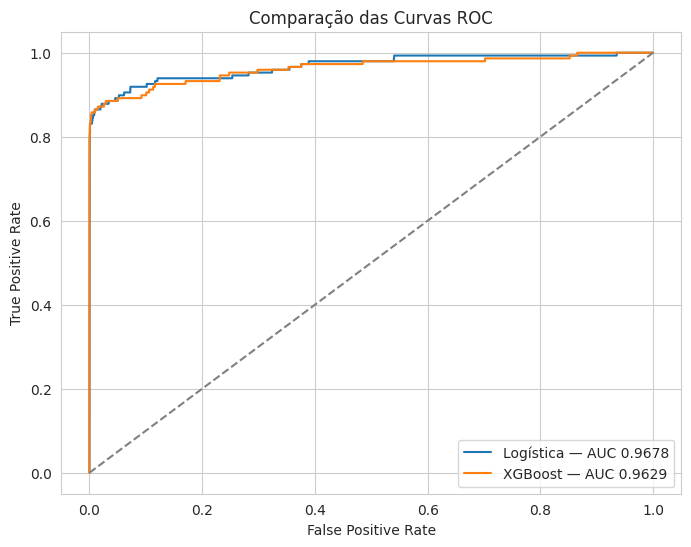

In [41]:
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logística — AUC {auc_log:.4f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost — AUC {auc_xgb:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparação das Curvas ROC")

plt.legend()

plt.show()

### **Precision-Recall do XGBoost**

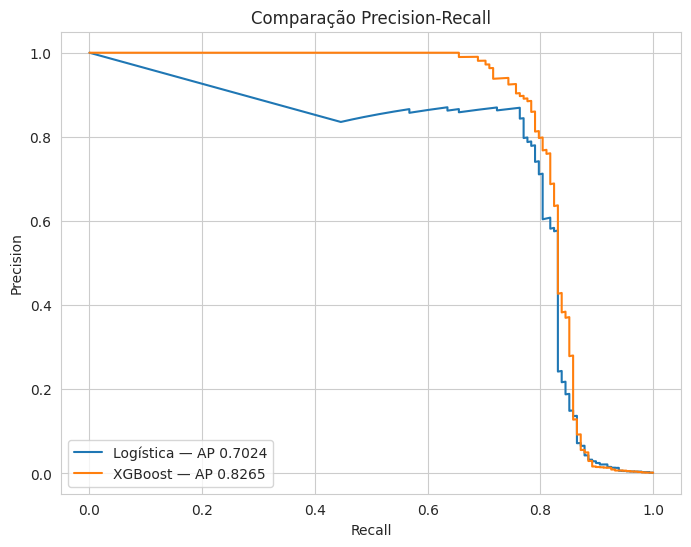

In [42]:
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

ap_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label=f"Logística — AP {ap_log:.4f}"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost — AP {ap_xgb:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Comparação Precision-Recall")

plt.legend()

plt.show()

### **Importância das variáveis**

A importância das variáveis permite observar quais características tiveram maior participação nas decisões do XGBoost.

In [43]:
feature_importances = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": xgb.feature_importances_
})

feature_importances = feature_importances.sort_values(
    "Importancia",
    ascending=False
)

feature_importances.head(15)

,Variavel,Importancia
14,V14,0.5114
17,V17,0.0883
10,V10,0.0640
4,V4,0.0355
12,V12,0.0270
11,V11,0.0172
29,Amount,0.0156
28,V28,0.0152
1,V1,0.0152
20,V20,0.0141


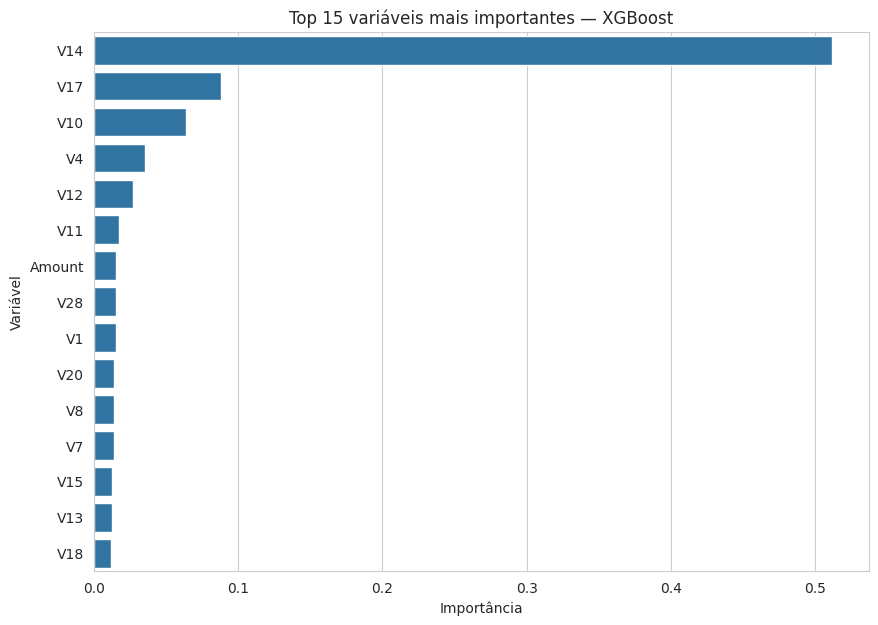

In [44]:
top_features = feature_importances.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importancia",
    y="Variavel"
)

plt.title("Top 15 variáveis mais importantes — XGBoost")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

### **Ajustes de hiperparâmetros**

O GridSearchCV testa diferentes combinações de hiperparâmetros e utiliza validação cruzada para comparar os resultados.

Neste projeto, o `recall` será utilizado como métrica de otimização, pois a identificação das fraudes é uma prioridade.

In [45]:
param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1]
}

In [46]:
grid = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=30,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [50, 100]},
             scoring='recall')

In [47]:
print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor recall médio na validação:")
print(grid.best_score_)

Melhores parâmetros:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Melhor recall médio na validação:
0.8488176964149504


In [48]:
best_xgb = grid.best_estimator_

y_pred_grid = best_xgb.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred_grid,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9997    0.9991    0.9994     85295
      Fraude     0.6205    0.8176    0.7055       148

    accuracy                         0.9988     85443
   macro avg     0.8101    0.9083    0.8525     85443
weighted avg     0.9990    0.9988    0.9989     85443



In [49]:
evaluate_model(
    "XGBoost + GridSearch",
    y_test,
    y_pred_grid
)

results_df = pd.DataFrame(results)

results_df

,Modelo,Precision,Recall,F1
0,Regressão Logística,0.0655,0.8784,0.1219
1,Regressão Logística + Threshold,0.2557,0.8311,0.3911
2,Random Forest,0.8309,0.7635,0.7958
3,Random Forest + Undersampling,0.0684,0.8649,0.1267
4,Random Forest + SMOTE,0.5794,0.8378,0.6851
5,XGBoost,0.8603,0.7905,0.8239
6,XGBoost + GridSearch,0.6205,0.8176,0.7055


### **SHAP**

O SHAP será utilizado para entender como as variáveis influenciam as previsões do XGBoost.

A análise global permite observar quais variáveis possuem maior impacto nas decisões do modelo.

Além disso, será analisada uma transação individual para observar quais características contribuíram para sua previsão.

In [56]:
explainer = shap.TreeExplainer(xgb)

X_shap = X_test.iloc[:500]

shap_values = explainer.shap_values(X_shap)

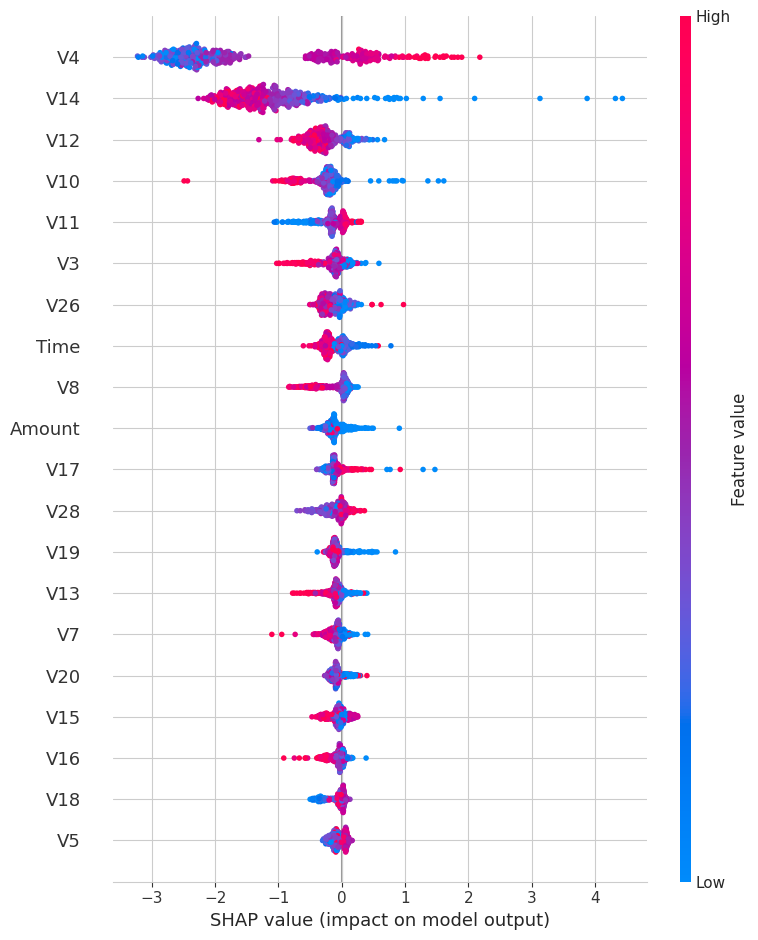

In [51]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns
)

### **SHAP: Importância global**

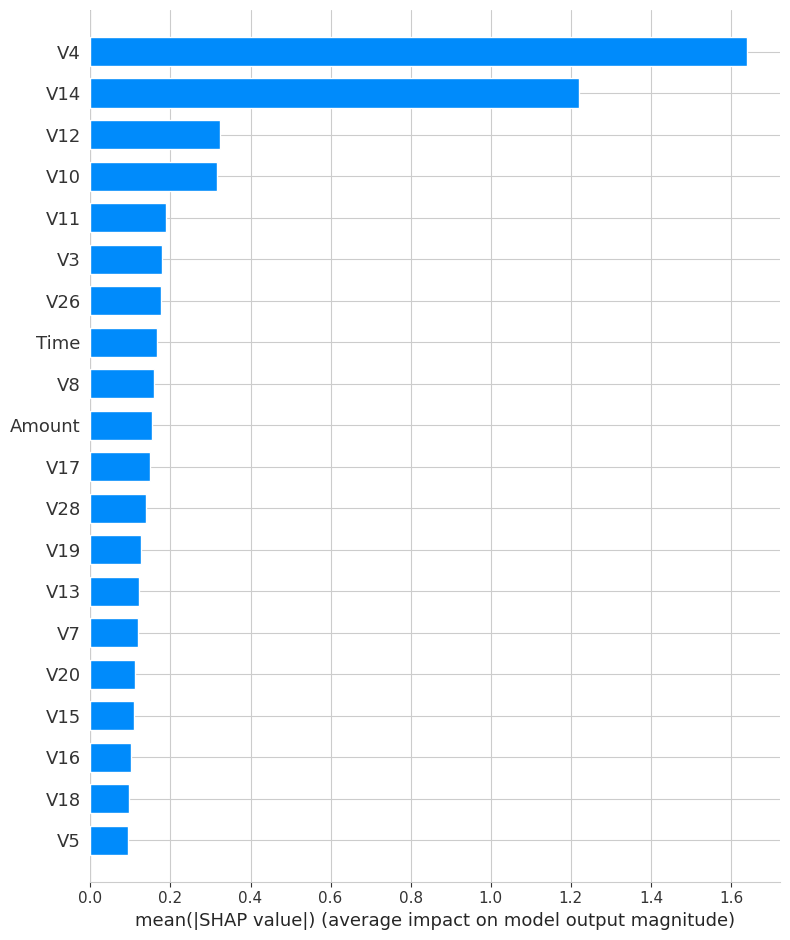

In [52]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar"
)

O gráfico de importância global do SHAP permite identificar as variáveis que mais contribuíram para as decisões do modelo.

As variáveis posicionadas no topo apresentam maior impacto médio nas previsões. Entretanto, a importância não significa necessariamente que uma variável cause fraude. Ela indica apenas que o modelo utilizou aquela informação de maneira relevante para realizar suas previsões.

### **Explicação de uma transação individual**

In [53]:
indice = 0

transacao = X_test.iloc[[indice]]

classe_real = y_test.iloc[indice]

previsao = xgb.predict(
    transacao
)[0]

probabilidade = xgb.predict_proba(
    transacao
)[0, 1]

print("Classe real:", classe_real)
print("Previsão:", previsao)
print(f"Probabilidade de fraude: {probabilidade:.4f}")

Classe real: 0
Previsão: 0
Probabilidade de fraude: 0.0000


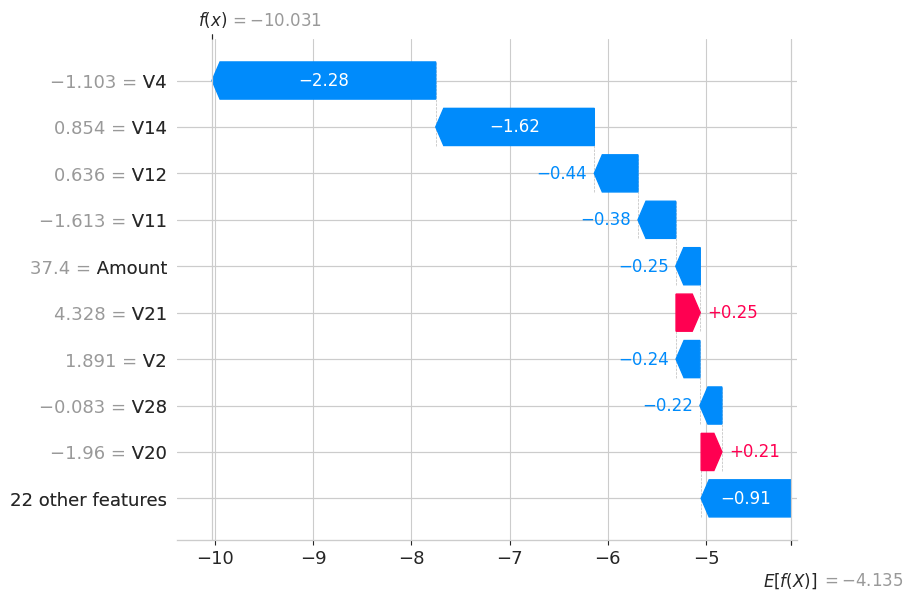

In [54]:
shap_single = explainer(
    transacao
)

shap.plots.waterfall(
    shap_single[0]
)

In [55]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "Recall",
    ascending=False
)

,Modelo,Precision,Recall,F1
0,Regressão Logística,0.0655,0.8784,0.1219
3,Random Forest + Undersampling,0.0684,0.8649,0.1267
4,Random Forest + SMOTE,0.5794,0.8378,0.6851
1,Regressão Logística + Threshold,0.2557,0.8311,0.3911
6,XGBoost + GridSearch,0.6205,0.8176,0.7055
5,XGBoost,0.8603,0.7905,0.8239
2,Random Forest,0.8309,0.7635,0.7958


### **Conclusão**

O projeto apresentou um pipeline completo para detecção de fraudes em transações de cartão de crédito.

Inicialmente, foi realizada uma análise exploratória da base, identificando o forte desbalanceamento entre transações normais e fraudulentas. Esse desbalanceamento demonstrou por que a acurácia não é suficiente para avaliar esse tipo de problema.

Na etapa de preparação foram realizadas a criação da variável Amount_log, a separação entre treinamento e teste e a padronização das variáveis quando necessária.

Foram treinados modelos de Regressão Logística, Random Forest e XGBoost. Também foram avaliadas estratégias de balanceamento utilizando undersampling e SMOTE.

A avaliação foi realizada principalmente utilizando precision, recall e F1-score para a classe de fraude. Além disso, foram analisadas as curvas ROC e Precision-Recall.

O limiar de decisão também foi investigado. A alteração do threshold mostrou que existe um equilíbrio entre identificar uma quantidade maior de fraudes e evitar que muitas transações normais sejam classificadas incorretamente como fraudulentas.

O XGBoost também foi analisado por meio da importância das variáveis e do SHAP, permitindo compreender quais características tiveram maior influência nas decisões do modelo.

Como próximos passos, o projeto poderia ser expandido com novas variáveis comportamentais, novos modelos, técnicas mais avançadas de otimização de hiperparâmetros e uma análise mais detalhada do custo de falsos positivos e falsos negativos.